In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.fftpack as ft
import h5py # for reading hdf5 files of data
from scipy.interpolate import interp1d, RegularGridInterpolator
import csv # for reading array geometry file
import os

fig_save_path = 'SPEC2VEC/figs/all_results_figures/das'

### Read DAS Data

In [4]:
firstFile = 'SPEC2VEC/data/das/PoroTomo_iDAS16043_160321073721.h5'
hf = h5py.File(firstFile, 'r')
print(hf.keys())

ch5 = hf.get('channel')
x5 = hf.get('x')
y5 = hf.get('y')
z5 = hf.get('z')

print('Number of channels: '+str(ch5.size)+'\n')
data = hf.get('das')
print(data.shape)

num_not_nan_x5 = np.count_nonzero(~np.isnan(x5[:]))
print("Number of non-NaN values in x5:", num_not_nan_x5)

num_not_nan_y5 = np.count_nonzero(~np.isnan(y5[:]))
print("Number of non-NaN values in x5:", num_not_nan_y5)

x5_non_nan = x5[~np.isnan(x5)]
y5_non_nan = y5[~np.isnan(y5)]

t = hf.get('t')
print(t)
startTime = t[0]
print(startTime)
dt = t[1]-t[0]
timeSec = dt+t-startTime
print("number of seconds per file: "+str(timeSec[-1]))

samplesPerSecond = data.shape[0]/timeSec[-1]
print("samples per second: "+str(samplesPerSecond))

<KeysViewHDF5 ['channel', 'crs', 'das', 't', 'trace', 'x', 'y', 'z']>
Number of channels: 8721

(30000, 8721)
Number of non-NaN values in x5: 8621
Number of non-NaN values in x5: 8621
<HDF5 dataset "t": shape (30000,), type "<f8">
1458545841.404309
number of seconds per file: 30.0
samples per second: 1000.0


### Plot One DAS File (Figure A)

In [24]:
"""
2D numpy array, storing seismic data such that each column represents a channel, 
and rows represent time (i.e. 0th axis is channel, 1st axis is time) 
    minSec: float, minimum time of interest (expressed in seconds beyond the start of someData) 
    maxSec: float, maximum time of interest (expressed in seconds beyond the start of someData) 
    minCh: int, minimum channel index of interest (don't forget offset of 0th channel if needed, as in BHS data) 
    maxCh: int, maximum channel index of interest (don't forget offset of 0th channel if needed, as in BHS data) 
    title: string, will be the title of your plot sampleRate: a float indicating number of samples per second (of each sensor)
"""
def plotSpaceTime(someData,minSec,maxSec,minCh,maxCh,title,sampleRate,file_save_details=None):
  # Basic error checking
  if (minSec >= maxSec) or (minSec < 0) or (maxSec*sampleRate > someData.shape[0]):
    print("ERROR in plotSpaceTime inputs minSec: "+str(minSec)+" or maxSec: "+str(maxSec))
    return
  if (minCh >= maxCh) or (minCh < 0) or (maxCh > someData.shape[1]):
    print("Error in plotSpaceTime inputs minCh: "+str(minCh)+" or maxCh: "+str(maxCh)+" referring to array with "+str(someData.shape[1])+" channels.")
    return
  
  # turn time range (in seconds) to indices
  minSecID = int(minSec*sampleRate) 
  maxSecID = int(maxSec*sampleRate) 

  # to get reasonable saturation, clip the values 
  percClip = 97
  clipVal = np.percentile(np.absolute(someData),percClip)
  # make the plot
  plt.figure()
  plt.imshow(someData[minSecID:maxSecID,minCh:maxCh],
             aspect='auto',interpolation='none',cmap='seismic',
             extent=(minCh,maxCh,maxSec,minSec),vmin=-clipVal,vmax=clipVal)
  plt.ylabel('time (s)',fontsize=12, fontweight='bold')
  plt.xlabel('channel',fontsize=12, fontweight='bold')
  plt.title(title,fontsize=14, fontweight='bold')
  plt.colorbar()
  plt.savefig(file_save_details, dpi=300)
  plt.show()

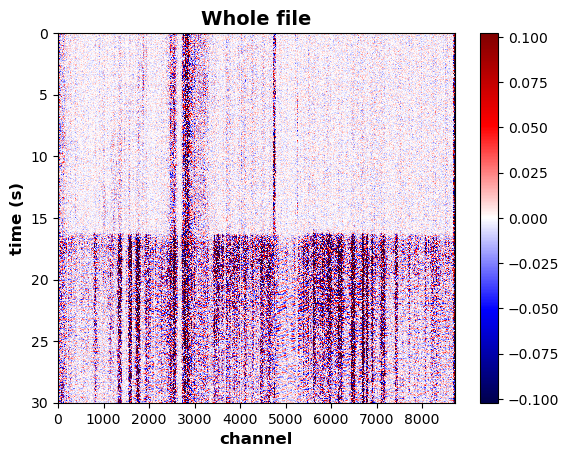

In [ ]:
plt_savename = 'das_raw_data.png'
file_save_details = os.path.join(fig_save_path,plt_savename)
plotSpaceTime(data,0,timeSec[-1],0,ch5.size-1,'Whole file',samplesPerSecond,file_save_details)

### Prepare Spectrograms

In [15]:
def plotArraySpec(dataArray, minSec, maxSec, 
                  minCh, maxCh, 
                  minFrq, maxFrq, sampleRate, title, 
                  scale='linear', isplot=False):

  # check for valid inputs (note- these checks aren't exhaustive)
  if(maxFrq <= minFrq):
    print("ERROR in plotArraySpec inputs: minFrq "+str(minFrq)+" >= maxFrq "+str(maxFrq))
    return
  if maxSec <= minSec:
    print("ERROR in plotArraySpec inputs: minSec "+str(minSec)+" >= maxSec "+str(maxSec))
    return
  if (scale != 'linear')  and (scale  != 'log10'): # only 2 scale keywords are recognized
    print("ERROR  in plotArraySpec inputs: scale keyword "+scale+" is not recognized")

  # figure out sample indices for time window of interest
  startTimeIdx =  int(minSec*sampleRate)
  endTimeIdx = int(maxSec*sampleRate)
  if endTimeIdx > dataArray.shape[0]: # another opportunity for error checking: don't request a time bigger than what's available.
    print("ERROR in plotArraySpec inputs: maxSec "+str(maxSec)+" exceeds last time in dataArray")

  # calculate the amplitude spectrum (not amplitude symmetry for +/- frequencies)
  spectrum = ft.fft(dataArray[startTimeIdx:endTimeIdx+1,minCh:maxCh+1],axis=0) 
  nFrqBins = int(spectrum.shape[0]/2) # number of frequency bins 
  amplitudeSpec =np.absolute(spectrum[:nFrqBins,:])

  # calculate indices corresponding to the frequencies of interest
  NyquistFrq = sampleRate/2.0 # the Nyquist frequency
  # make sure maxFrq doesn't exceed Nyquist  frequency
  if(maxFrq > NyquistFrq):
    print("ERROR in plotArraySpec inputs: maxFrq "+str(maxFrq)+" >= Nyquist frequency "+str(NyquistFrq)+" indicated by sampleRate "+str(sampleRate))
    return
  # convert frequencies to an index in the array
  HzPerBin = NyquistFrq/float(nFrqBins) 
  minFrqIdx =  int(minFrq/HzPerBin) 
  maxFrqIdx =  int(maxFrq/HzPerBin)
  frqs = np.linspace(minFrqIdx*HzPerBin,maxFrqIdx*HzPerBin,num=(maxFrqIdx-minFrqIdx+1)-1)
  channels = np.arange(minCh,maxCh+1)
  
  # actually do the plot
  if isplot:
    plt.figure()
    if scale  == 'linear':
      plt.imshow(amplitudeSpec[minFrqIdx:maxFrqIdx,:],aspect='auto',interpolation='none',cmap='inferno',extent=(minCh,maxCh,maxFrq,minFrq))
    elif scale == 'log10':
      plt.imshow(np.log10(amplitudeSpec[minFrqIdx:maxFrqIdx,:]),aspect='auto',interpolation='none',cmap='inferno',extent=(minCh,maxCh,maxFrq,minFrq)) 
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Channel')
    plt.colorbar()
    plt.title(title)

  spectro = np.log10(amplitudeSpec[minFrqIdx:maxFrqIdx,:])
  vmax = np.percentile(spectro, 99)  
  vmin = np.percentile(spectro, 1)  

  spectro[spectro > vmax] = vmax
  spectro[spectro < vmin] = vmin

  return spectro, frqs, channels

In [16]:
minFrq = 0.5
maxFrq = 200

# choose which time window to investigate
startSec = 0
endSec = 4

# choose which channels to view
startCh = 0
endCh = ch5.size - 1

spectrograms = []
window_length = 5
total_duration = 30

minFrq = 0.5
maxFrq = 200
samplesPerSecond = 1000.0
startCh = 0
endCh = ch5.size - 1
interp_shape = (256,256)

interp_imgs = []
interp_ts = []
interp_fs = []

for i in range(0, total_duration, window_length):
    startSec = i
    endSec = i + window_length
    spec, frq, chns = plotArraySpec(
        data, startSec, endSec, startCh, endCh,
        minFrq, maxFrq, samplesPerSecond,
        f'Array-wide log amplitude spectrum {startSec}-{endSec}s', 'log10'
    )
    spectrograms.append(spec)

    t_new = np.linspace(chns.min(), chns.max(), interp_shape[1])
    f_new = np.linspace(frq.min(), frq.max(), interp_shape[0])
    interp_func = RegularGridInterpolator((frq, chns), spec, method='slinear', bounds_error=False, fill_value=None) # cant do nearest interpolatation becuase it makes the smallest image the best becuase of repeating values #using nearest since it maintains the texture; using pchip since we have overshoot in the images
    # meshgrid for new coordinates
    T_new, F_new = np.meshgrid(t_new, f_new)
    points = np.array([F_new.flatten(), T_new.flatten()]).T
    img_interp = interp_func(points).reshape(interp_shape)

    interp_imgs.append(img_interp)
    interp_ts.append(t_new)
    interp_fs.append(f_new)

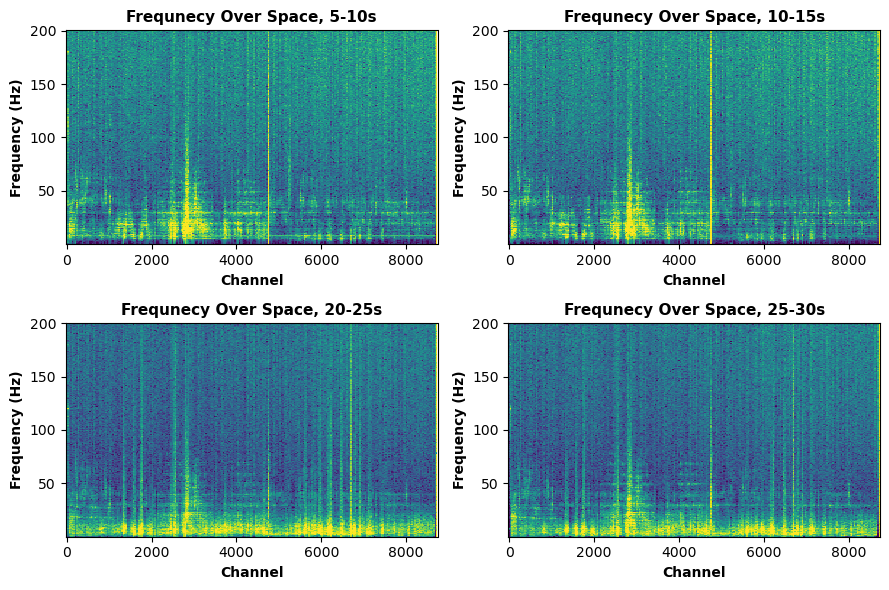

In [63]:
plot_idx = [1,2,4,5]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for idx, ax in enumerate(axes.flat):
    if idx < len(interp_imgs):
        ax.pcolormesh(interp_ts[plot_idx[idx]],interp_fs[plot_idx[idx]],interp_imgs[plot_idx[idx]])
        ax.set_title(f'Frequnecy Over Space, {plot_idx[idx] * window_length}-{(plot_idx[idx] + 1) * window_length}s',fontsize=11, fontweight='bold')
        ax.set_xlabel('Channel', fontsize=10, fontweight='bold')
        ax.set_ylabel('Frequency (Hz)', fontsize=10, fontweight='bold')
    else:
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'das_spectrograms_interpolated.png'), dpi=300)
plt.show()

### Prepare Noise Segments

In [26]:
noise_spec, nf, nc = plotArraySpec(data, 0, 15, 5000, 8000, minFrq, maxFrq, samplesPerSecond, 'Array-wide log amplitude spectrum','log10')
t_new = np.linspace(5000, 8000, interp_shape[1])
f_new = np.linspace(0.5, 200, interp_shape[0])
interp_func = RegularGridInterpolator((nf, nc), noise_spec, method='slinear', bounds_error=False, fill_value=None) # cant do nearest interpolatation becuase it makes the smallest image the best becuase of repeating values #using nearest since it maintains the texture; using pchip since we have overshoot in the images

# meshgrid for new coordinates
T_new, F_new = np.meshgrid(t_new, f_new)
points = np.array([F_new.flatten(), T_new.flatten()]).T
noise_interp = interp_func(points).reshape(interp_shape)

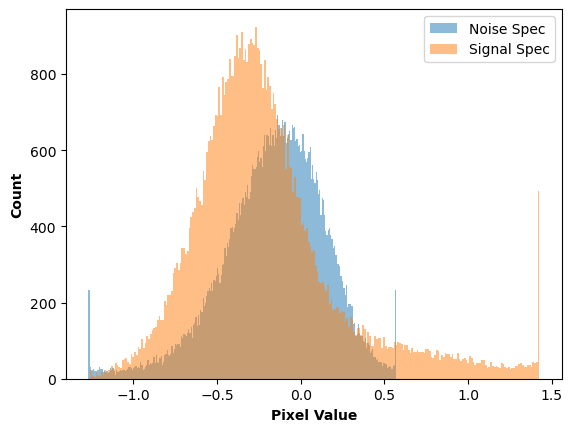

In [27]:
plt.hist(noise_interp.flatten(), bins=256, label='Noise Spec', alpha=0.5)
plt.hist(interp_imgs[3].flatten(), bins=256, label='Signal Spec', alpha=0.5)
plt.xlabel('Pixel Value', fontsize=10, fontweight='bold')
plt.ylabel('Count', fontsize=10, fontweight='bold')
plt.legend()
plt.savefig(os.path.join(fig_save_path, 'das_spectrogram_histogram_comparison.svg'), dpi=300)
plt.show()

In [ ]:
save_path = 'SPEC2VEC/data/das/das_noise_reference.h5'
spec_dict = {}
spec_dict['das_noise_key'] = {'image':np.expand_dims(noise_interp, axis=[0,1])}
                       
with h5py.File(save_path, "w") as h5f:
    for key in spec_dict.keys():
        grp = h5f.create_group(key)
        grp.create_dataset('image', data=spec_dict[key]['image'])

### SPEC2VEC on DAS

#### Import Libraries

In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Systems and Standard lib
import requests
import io
import os
import glob
import datetime
import random
import h5py
import inspect
import sys
from itertools import combinations

# Data Manipulation and Visualization Std. lib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pl
from matplotlib import ticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from matplotlib.lines import Line2D
import matplotlib.markers as mmarkers
from scipy.spatial.distance import mahalanobis


# Imaging and CV lib
from PIL import Image
from scipy.ndimage import gaussian_filter1d

# Signal Processing lib
from scipy.spatial import distance_matrix
from scipy.spatial.distance import jensenshannon
from scipy import signal
from scipy.signal import chirp
from scipy.fft import fft
from scipy.interpolate import interp1d

# Metrics lib
from scipy.stats import  wasserstein_distance,wasserstein_distance_nd
import antropy as ant
import tsfel
import ordpy
from hilbert import decode, encode
import shap

# ML lib
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

# Waveform Simulations
from jwave.geometry import *
import porespy as ps
import inspect
inspect.signature(ps.generators.fractal_noise)

# Home libs
sys.path.append(os.path.abspath('.'))
from SPEC2VEC.src.utils.data_preparations import *
from SPEC2VEC.src.utils.noise_lib import *
from SPEC2VEC.src.utils.spectograms_lib import *
from SPEC2VEC.src.utils.gisqa_compute_updated import *
from SPEC2VEC.src.utils.gisqa_plotting import *
from SPEC2VEC.src.utils.gisqa_helper import *
from SPEC2VEC.src.utils.complex_waveform_models import Simulator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Stat+Texture Metrics

In [ ]:
entp_columns = [
       'permutation_entropy_antropy', 
       'spectral_entropy_antropy',
       'svd_entropy_antropy', 
       'petrosian_fd_antropy', 
       'detrended_fluctuation_antropy', 
       'hjorth_mobility_antropy',
       'hjorth_complexity_antropy', 
       'higuchi_fd_antropy',
       'normalized_permutation_entropy_ordpy',
       'statistical_complexity_entropy_ordpy', 
       'fisher_shannon_ordpy',
       'global_node_entropy_ordpy', 
       'renyi_complexity_entropy_long_ordpy',
       'renyi_stat_complexity_long_ordpy',
       'tsallis_complexity_entropy_long_ordpy',
       'tsallis_stat_complexity_long_ordpy',
       'weighted_permutation_entropy_ordpy', 
       'missing_links_ordpy',
       '0_Absolute energy',
       '0_Average power',
       '0_Kurtosis', '0_Lempel-Ziv complexity', '0_Mean','0_Median','0_Skewness', '0_Standard deviation',
       '75th_percentile',
       '25th_percentile',
       'label']

In [37]:
## Refernece File params
all_names = ['TFR0to5','TFR5to10','TFR10to15','TFR15to20','TFR20to25','TFR25to30']
all_imgs = interp_imgs.copy()
all_ts= interp_ts.copy()
all_fs= interp_fs.copy()

## Compute the Metrics Dataset
giq = GISQAPipeline()
spec_pointwise_metrics_df = giq.compute_pointwise_metrics_from_spec(all_names, all_imgs,
                                                                    is_hilbertize = 1,
                                                                    is_normalize_stat = 0,
                                                                    is_normalize_entropy = 0,
                                                                    is_best_features = 0,
                                                                    ordpydx = 6, antropydx = 6,
                                                                    metrics_list=entp_columns, hilbert_locs=None)

In [38]:
all_imgs[0].shape, all_fs[0].shape, all_ts[0].shape

((256, 256), (256,), (256,))

#### PDFSI Metrics

In [ ]:
save_folder = 'SPEC2VEC/figs/all_results_figures/das/pdfsi_results'
save_path = save_folder
binary_keys = ['erdos_renyi_graph_0.4','erdos_renyi_graph_0.8','perlin_noise_0.4','perlin_noise_0.8']
noisebnk_path = 'TEMP_PROJECTS/das_processing/data/das_noise_reference.h5'
noisebnk_keys = ['das_noise_key']
all_keys = ['das_noise_key','das_noise_key','das_noise_key','das_noise_key','das_noise_key','das_noise_key']

gipl = GISQAPipeline()
glzm_pairwise_metrics_df = pd.DataFrame([])
updated_spec_details_dict = {}
for t_plot, f_plot, spec_img, filename, key in zip(all_ts,all_fs,all_imgs,all_names,all_keys):
    pairwise_metrics_temp, updated_spec_details = gipl.execute_pairwise_pipleine(t_plot=t_plot,
                                                                                 f_plot=f_plot,
                                                                                 spec_img=spec_img,
                                                                                 noisebnk_path=noisebnk_path,
                                                                                 noise_cutoff=99,
                                                                                 noisebnk_keys=noisebnk_keys,
                                                                                 binary_keys=binary_keys,
                                                                                 filename=filename,
                                                                                 gmm_mean_threshold=0.025,
                                                                                 optimization_params={'type':'exponential',
                                                                                                      'start':1,'end':1,'slope':1},
                                                                                 save_path=save_path,save_all_plots=True,
                                                                                 best_neighbour_key=key,
                                                                                 min_zone_size_thrshld=2)

    glzm_pairwise_metrics_df = pd.concat([glzm_pairwise_metrics_df,pairwise_metrics_temp], axis=0)
    updated_spec_details_dict[filename] = updated_spec_details

#### Texture Metrics Comparison For Similarity

<Figure size 1200x900 with 0 Axes>

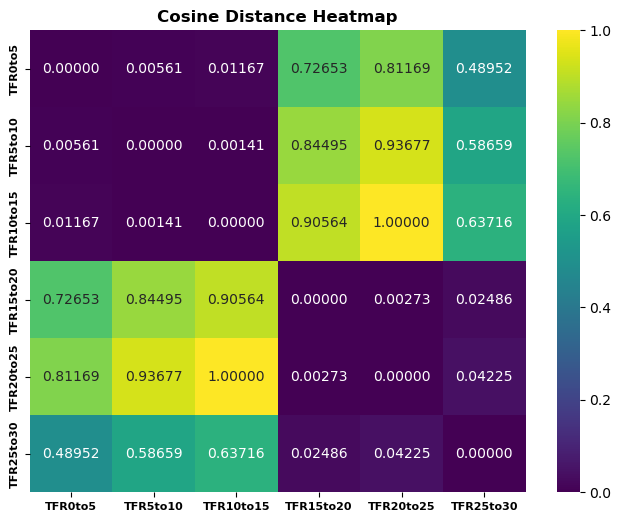

In [ ]:
from scipy.spatial.distance import cdist

spec_pointwise_metrics_entp_df = spec_pointwise_metrics_df.copy()
features = spec_pointwise_metrics_entp_df.drop(columns=['label']).values

# Compute cosine distances
cos_dist = cdist(features, features, metric='cosine')
cos_dist = cos_dist/np.max(cos_dist) 

plt.figure(figsize=(8,6))
sns.heatmap(
    cos_dist, 
    xticklabels=spec_pointwise_metrics_entp_df['label'], 
    yticklabels=spec_pointwise_metrics_entp_df['label'], 
    cmap='viridis', annot=True, fmt=".5f"
)
plt.xticks(fontsize=8, fontweight='bold')
plt.yticks(fontsize=8, fontweight='bold')
plt.title('Cosine Distance Heatmap', fontsize=12, fontweight='bold')
plt.savefig(os.path.join(fig_save_path, 'das_spec2vec_cosine_distance_heatmap.svg'), dpi=300)
plt.show()

#### Saptial Metrics COmputations

In [60]:
filtered_cols = [col for col in glzm_pairwise_metrics_df.columns if col.endswith('_stg1')]
glzm_pairwise_metrics_df_stg1 = glzm_pairwise_metrics_df[filtered_cols].copy()
glzm_pairwise_metrics_df_stg1.loc[:,'label'] = glzm_pairwise_metrics_df.loc[:,'label']

filtered_cols = [col for col in glzm_pairwise_metrics_df.columns if col.endswith('_stg2')]
glzm_pairwise_metrics_df_stg2 = glzm_pairwise_metrics_df[filtered_cols].copy()
glzm_pairwise_metrics_df_stg2.loc[:,'label'] = glzm_pairwise_metrics_df.loc[:,'label']

glzm_pairwise_metrics_df_stg1_scaled = MinMaxScaler(feature_range=(0.1,0.9)).fit_transform(glzm_pairwise_metrics_df_stg1.iloc[:,:-1])
glzm_pairwise_metrics_df_stg1_scaled = pd.DataFrame(glzm_pairwise_metrics_df_stg1_scaled, columns = glzm_pairwise_metrics_df_stg1.columns[:-1], 
                                                        index=glzm_pairwise_metrics_df_stg1['label'].tolist())

glzm_pairwise_metrics_df_stg2_scaled = MinMaxScaler(feature_range=(0.1,0.9)).fit_transform(glzm_pairwise_metrics_df_stg2.iloc[:,:-1])
glzm_pairwise_metrics_df_stg2_scaled = pd.DataFrame(glzm_pairwise_metrics_df_stg2_scaled, columns = glzm_pairwise_metrics_df_stg2.columns[:-1], 
                                                        index=glzm_pairwise_metrics_df_stg2['label'].tolist())                                                       

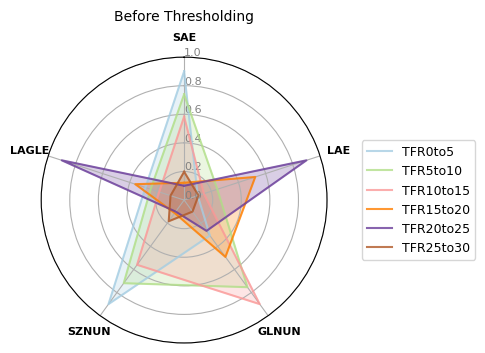

In [61]:
fig, axes = plt.subplots(1,1, figsize=(5, 5), subplot_kw=dict(polar=True))
ax1 = axes
b4_area = gisqa_plots.plot_multi_row_radar_chart(
    df = glzm_pairwise_metrics_df_stg1_scaled.iloc[:,:-1], column_lables = ['SAE','LAE','GLNUN','SZNUN','LAGLE'], title='Before Thresholding',
    ax=ax1, cmap='Paired')

plt.tight_layout(); 
plt.savefig(os.path.join(fig_save_path, 'das_pairwise_metrics_radar_chart.svg'), dpi=300)
plt.show()

#### Additional Plotting

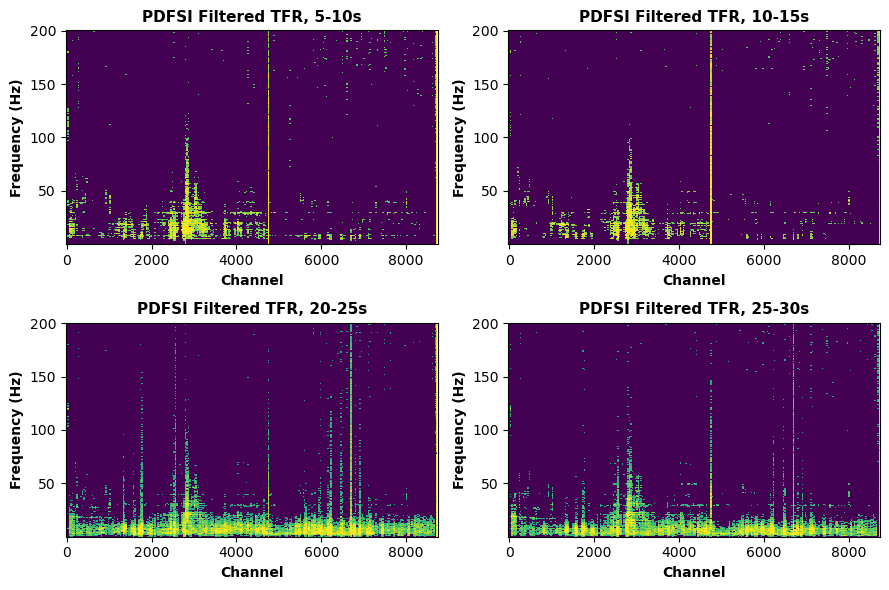

In [77]:
plot_idx = ['TFR5to10','TFR10to15','TFR20to25','TFR25to30']
plot_vals = [1,2,4,5]
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for idx, ax in enumerate(axes.flat):
    if idx < len(interp_imgs):
        ax.pcolormesh(updated_spec_details_dict[plot_idx[idx]]['t_plot'],
                      updated_spec_details_dict[plot_idx[idx]]['f_plot'],
                      updated_spec_details_dict[plot_idx[idx]]['spec_image_noise_cleaned'])
        ax.set_title(f'PDFSI Filtered TFR, {plot_vals[idx] * window_length}-{(plot_vals[idx] + 1) * window_length}s',fontsize=11, fontweight='bold')
        ax.set_xlabel('Channel', fontsize=10, fontweight='bold')
        ax.set_ylabel('Frequency (Hz)', fontsize=10, fontweight='bold')
    else:
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'das_pdfsi_filt_spectrograms.png'), dpi=300)
plt.show()

In [104]:
def plot_labeled_spec_das(t_plot, f_plot, labeled_spec_image, filename=None, save_path=None, **kwargs):
    colors = ['#F5F5F5', '#228B22', '#00BFFF', '#F58231', '#911EB4', '#191970']
    colors = colors if len(np.unique(labeled_spec_image)) == len(colors) else colors[:len(np.unique(labeled_spec_image))]
    cmap = kwargs.get('cmap', None)
    kde = kwargs.get('kde',1)
    bins= kwargs.get('bins',25)
    cmap = cmap if cmap else matplotlib.colors.ListedColormap(colors) 

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.pcolormesh(t_plot, f_plot, labeled_spec_image, cmap=cmap)
    ax.set_xlabel('Time (s)',fontsize=10, fontweight='bold'); 
    ax.set_ylabel('Frequency (Hz)',fontsize=10, fontweight='bold'); 
    fig.colorbar(im, ax=ax, orientation='vertical')
    if kde:
        freq_dist = []
        for fs in range(0,f_plot.shape[0]):
            freq_dist.append(np.sum(labeled_spec_image[fs,:]).item())
        freq_dist_df = pd.DataFrame(np.repeat(f_plot,freq_dist),columns=['freq_count'])
        divider = make_axes_locatable(ax)
        ax_histy = divider.append_axes("right", 1, pad=0.1, sharey=ax)
        ax_histy.yaxis.set_tick_params(labelleft=False)
        sns.histplot(data=freq_dist_df, y='freq_count', bins=25, kde=True, ax=ax_histy, color='gray', line_kws={'linewidth':'2'})
        ax_histy.lines[0].set_color('crimson'); ax_histy.set_xlabel('Pixel Count')
        ax.set_title(filename, fontsize=11, fontweight='bold')
        plt.savefig(save_path, dpi=300)
        plt.show()

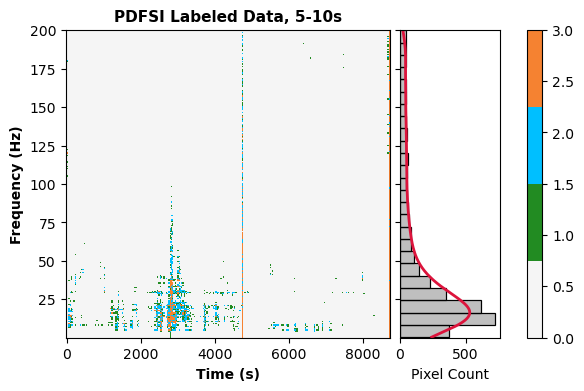

In [111]:
key='TFR5to10'
title = 'PDFSI Labeled Data, 5-10s'

t_plot = updated_spec_details_dict[key]['t_plot'],
f_plot = updated_spec_details_dict[key]['f_plot'],
labeled_spec_image = updated_spec_details_dict[key]['labeled_spec_image']
save_path = os.path.join(fig_save_path, f'das_labeled_spectrogram_{key}.png')

plot_labeled_spec_das(t_plot[0], f_plot[0], labeled_spec_image, filename=title, save_path=save_path)

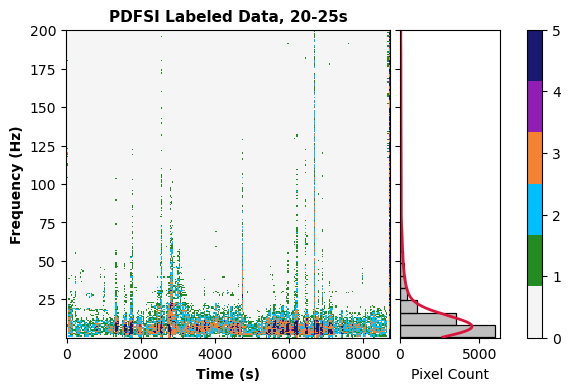

In [112]:
key='TFR20to25'
title = 'PDFSI Labeled Data, 20-25s'

t_plot = updated_spec_details_dict[key]['t_plot'],
f_plot = updated_spec_details_dict[key]['f_plot'],
labeled_spec_image = updated_spec_details_dict[key]['labeled_spec_image']
save_path = os.path.join(fig_save_path, f'das_labeled_spectrogram_{key}.png')

plot_labeled_spec_das(t_plot[0], f_plot[0], labeled_spec_image, filename=title, save_path=save_path)

#### PDFSI Process Speed Without Plotting

In [ ]:
updated_spec_details_list = []
for t_plot, f_plot, spec_img, filename, key in zip(all_ts,all_fs,all_imgs,all_names,all_keys):
    pairwise_metrics_temp, updated_spec_details = gipl.execute_pairwise_pipleine(t_plot=t_plot,
                                                                                    f_plot=f_plot,
                                                                                    spec_img=spec_img,
                                                                                    noisebnk_path=noisebnk_path,
                                                                                    noise_cutoff=99,
                                                                                    noisebnk_keys=noisebnk_keys,
                                                                                    binary_keys=binary_keys,
                                                                                    filename=filename,
                                                                                    gmm_mean_threshold=0.025,
                                                                                    optimization_params={'type':'exponential',
                                                                                                        'start':1,'end':1,'slope':1},
                                                                                    save_path=save_path,save_all_plots=False,
                                                                                    best_neighbour_key=key,
                                                                                    min_zone_size_thrshld=2)
    updated_spec_details_list.append(updated_spec_details)